In [9]:
import sys,copy,os,inspect
if hasattr(sys.modules[__name__], '__file__'):
    _file_name = __file__
else:
    _file_name = inspect.getfile(inspect.currentframe())
CURRENT_FILE_PATH = os.path.dirname(_file_name)
sys.path.append(os.getcwd()+"/../neuronVis")
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline

import IONData 
iondata = IONData.IONData()
import pickle
import Scene,NeuronProcess,SwcLoader
import numpy as np
import Visual as nv

In [10]:
neuronList1=[
    221244001,
221244002,
221245001,
221245002,
221250002,
221250003,
221250004,
221250005,
221248001
]
neuronList2=[
221247002,
221246001,
221246002,
221246003,
221246006,
221246007,
221246008,
221246010
]
neuronList1 = np.array(neuronList1,dtype=str)
neuronList2 = np.array(neuronList2,dtype=str)

In [11]:

def GetFirstOrderEdges(edgesForCluster,parentedge):
    for child in parentedge.children:
        if child.order!=0:
            edge = SwcLoader.Edge()
            edgesForCluster.append(edge)
            for p in child.data:
                edge.addPoint(SwcLoader.Point([p.index,p.type,p.x,p.y,p.z,p.ratio,p.parentIndex]))
            child.maxDepth=1
            GetFirstOrderEdges(edgesForCluster,child)

In [20]:
neuronvis = nv.neuronVis(renderModel=1)
neuronArbor={}
neuronTrunk={}
neuronALLproj={}
for neuron in neuronList2[:]:
    terminalArbor=[]
    print(neuron[0:6], neuron[6:9]+'.swc')
    neuronProperty = iondata.getNeuronPropertyByID(neuron[0:6], neuron[6:9]+'.swc')['projectregion']
    neuronT = iondata.getNeuronTreeByID(neuron[0:6], neuron[6:9]+'.swc')
    neuronT.dendriteHide=True
    NeuronProcess.CalculateBranchMaxDepth(neuronT)
    mainbranch=[]
    if neuronT.rootAxonEdge is None:
        continue
    for edge in neuronT.edges:

        if edge.maxDepth>neuronT.rootAxonEdge.maxDepth*0.3:
            edge.order=0
            mainbranch.append(edge)
    for edge in mainbranch:
        for child in edge.children:
            if child.order!=0:
                NeuronProcess.OrderChildren(neuronT,child,1)
        pass
    # for child in neuronT.rootAxonEdge.children:
    # 	# if child.order!=0:
    # 		NeuronProcess.OrderChildren(neuronT,child,1)

    for edge in mainbranch:
        for child in edge.children:
            if child.order!=0:
                GetFirstOrderEdges(terminalArbor,child)
    if neuron==neuronList2[1]:
        newneuron=SwcLoader.NeuronTree()
        if len(mainbranch):
            newneuron.edges= terminalArbor
            newneuron.rootAxonEdge = neuronT.rootAxonEdge
            newneuron.root=neuronT.root
        neuronvis.addNeuronTree(newneuron,'neuronname',depthIntensity=False)
        neuronvis.render.run()
    neuronArbor[neuron]=terminalArbor
    neuronTrunk[neuron]=mainbranch
    neuronALLproj[neuron]=neuronProperty

221247 002.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/221247/002.swc
221246 001.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/221246/001.swc
221246 002.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/221246/002.swc
221246 003.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/221246/003.swc
221246 006.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/221246/006.swc
221246 007.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/221246/007.swc
221246 008.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/221246/008.swc
221246 010.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/221246/010.swc


In [13]:
neuronALLproj

{'221244001': {'AHN': 160.988251,
  'AMd': 350.769318,
  'APN': 917.693787,
  'AV': 184.142334,
  'CB': 1177.107422,
  'CENT2': 307.227173,
  'CENT3': 155.310333,
  'CL': 3672.156982,
  'CLI': 1005.76825,
  'CM': 2714.727295,
  'CUN': 581.51178,
  'DR': 709.65625,
  'GRN': 2870.388672,
  'HY': 2334.481445,
  'IAD': 1735.210815,
  'IAM': 1239.355469,
  'IF': 1274.832642,
  'IMD': 313.665314,
  'IO': 2611.341553,
  'IRN': 12067.628906,
  'IVn': 118.280243,
  'KF': 157.532974,
  'LDT': 601.087158,
  'LHA': 3298.28125,
  'LP': 891.585083,
  'LRNm': 1109.933105,
  'LRNp': 317.330475,
  'MARN': 5408.510742,
  'MB': 5326,
  'MD': 9343.647461,
  'MDRNd': 4256.550293,
  'MDRNv': 219.927505,
  'MRN': 15161.561523,
  'MV': 434.284424,
  'MY': 6440.160645,
  'NI': 212.018448,
  'NLL': 305.943451,
  'NPC': 1252.129395,
  'P': 5820.613281,
  'P5': 2076.713623,
  'PAG': 27361.638672,
  'PAL': 163.313629,
  'PARN': 1529.187866,
  'PB': 9492.603516,
  'PCG': 1907.251831,
  'PCN': 7247.194336,
  'PF': 1

In [14]:
res,path = iondata.getFileFromServer("annotation_10_2017.nrrd")
import nrrd
annotation,header = nrrd.read(path)

In [15]:

neuronArborLen={}
for neuron ,trunk in neuronArbor.items():
    trunkLength={}
    # for c in range(5):
    #     trunkLength[c]={}
    lenMap ={}
    for i in range(len(trunk)):
        edge=trunk[i]
        for j in range(len(edge.data)-1):
            p = edge.data[j]
            if int(p.x/10)<annotation.shape[0]:
                region = int(annotation[int(p.x/10),int(p.y/10),int(p.z/10)])
            else:
                region=0
            length = np.linalg.norm(np.array(edge.data[j].xyz)-np.array(edge.data[j+1].xyz))
            if region not in lenMap.keys():
                lenMap[region]=0
            lenMap[region]+=length
    print(lenMap)
    neuronArborLen[neuron]=lenMap
        # for k,v in lenMap.items():
        #     trunkLength[edge.maxDepth][k]+=v

{0: 11013.553348004818, 1048: 1697.4631567001343, 978: 5254.821646690369, 354: 6008.434302985668, 136: 7045.006965458393, 1093: 5907.804060935974, 105: 151.53273737430573, 771: 4431.19601303339, 114: 578.5321680307388, 122: 148.60110712051392, 841: 67.02733892202377, 146: 4597.225560367107, 658: 490.22748523950577, 612: 314.649387717247, 867: 7179.582758784294, 616: 120.80326747894287, 313: 4091.070629119873, 534: 1608.4325205683708, 898: 1742.4725873470306, 162: 616.1634697914124, 795: 19925.515229970217, 326: 266.3205554485321, 128: 8417.698451042175, 271: 373.9943361878395, 381: 860.7451680898666, 1097: 2321.3437736034393, 797: 6431.793725520372, 470: 669.0199412107468, 102: 39.187519669532776, 946: 159.70028030872345, 194: 3313.412907600403, 88: 166.13028478622437, 803: 208.3815302848816, 63: 1641.2708702087402, 1009: 55.8569039106369, 6: 648.2409416437149, 342: 134.76462352275848, 718: 298.49417293071747, 549: 1336.5437324047089, 422: 1791.8918669223785, 741: 1350.0832936167717, 9

[3267.727381527424, 0, 1373.984004855156, 778.4833097457886, 7337.1172115802765, 314.649387717247, 2652.4027639627457, 5503.736653923988, 1350.0738561749458, 17.5181006193161, 0, 1648.5774665474892, 0, 0, 6431.793725520372, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4437.620736479759, 0]
[102.92135441303253, 293.48721569776535, 0, 431.1590359210968, 115.26212084293365, 3917.6689788103104, 0, 590.0876359939575, 779.6195269823074, 612.6196690201759, 0, 0, 0, 0, 2343.767486333847, 265.8267718553543]
[273.72144532203674, 0, 131.62770438194275, 1349.354352593422, 977.4993430376053, 5455.1011699438095, 1887.1623811721802, 1897.1404772400856, 2927.0561685562134, 1267.1335867643356, 0, 0, 0, 0, 456.4775255918503, 536.5637108683586]
[0, 0, 0, 0, 837.8835058808327, 1096.2148625850677, 0, 0, 0, 0, 0, 4680.73044782877, 0, 0, 4155.57901853323, 1363.5069016218185]
[0, 0, 0, 0, 0, 0, 0, 0, 79.3732140660286, 0, 550.5385722517967, 0, 0, 1380.5631400346756, 0, 0]
[0, 0, 0, 387.0014254450798, 0, 0, 22

<AxesSubplot:>

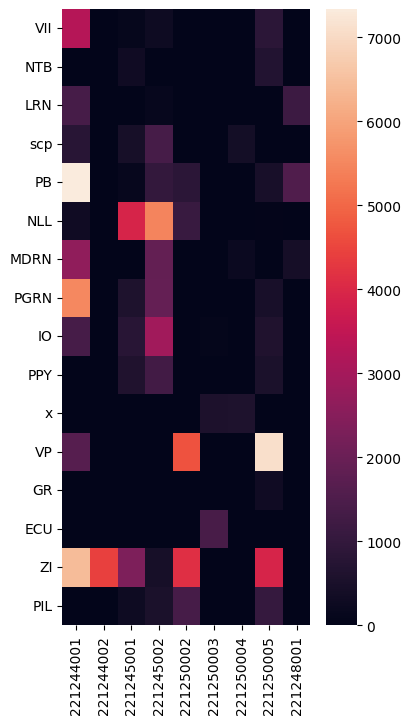

In [16]:
import BrainRegion as BR 
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline
fig,ax = plt.subplots(figsize=(4,8))

targetRegions=['VII','NTB','LRN','scp','PB','NLL','MDRN','PGRN','IO','PPY','x','VP','GR','ECU','ZI','PIL']
neuronProject=[]
for neuron ,arborLen in neuronArborLen.items():
    # print(arborLen)
    br = BR.BrainRegion()
    br.praseJson()
    brproperty=BR.RegionProperty(copy.deepcopy(br))
    brproperty.setProperty(arborLen)
    regionProj=[]
    for targetRegion in targetRegions:
        regionsum = brproperty.getSumProperty(targetRegion)
        regionProj.append(regionsum)
    print(regionProj)
    neuronProject.append(regionProj)
sns.heatmap(pd.DataFrame(neuronProject,index=list(neuronArborLen.keys()),columns=targetRegions).T)

## all project - trunk

In [12]:
import BrainRegion as BR 
import numpy as np
br = BR.BrainRegion()
br.praseJson()
# print(neuronALLproj)
for neuron,proj in neuronALLproj.items():
    trunkLen = neuronTrunkLen[neuron]
    brproperty=BR.RegionProperty(copy.deepcopy(br))
    brproperty.setProperty(proj)
    regionPropertyList = brproperty.getRegionPropertyList()

    print(trunkLen)
    print(regionPropertyList)
    for region in regionPropertyList:
        if region[1] in trunkLen.keys():
            region[2]-=trunkLen[region[1]]
    print(regionPropertyList)
    
    


{0: 6011.34566795826, 136: 4785.110102266073, 1107: 143.80616450309753, 1048: 424.19808822870255, 1093: 2489.8002989292145, 658: 385.28875946998596, 146: 419.5125341415405, 549009215: 875.7922857105732, 534: 1318.6045508384705, 867: 2050.8929421305656, 771: 1325.93483543396, 1052: 930.3390047550201, 128: 5486.243067622185, 313: 1241.81682908535, 634: 526.8888853788376, 795: 4860.525848686695, 609: 628.3072876930237, 59: 309.5343037843704, 362: 158.10443997383118, 549009203: 321.1052550673485, 158: 135.75287401676178, 50: 324.80792224407196, 549: 324.15400993824005, 575: 500.5808836221695, 218: 832.8384230732918, 155: 49.31368792057037, 255: 216.32560634613037, 907: 341.2058244943619, 1113: 497.11600309610367, 599: 532.4585407972336, 15: 153.9056831598282, 616: 435.14076191186905, 512: 163.5995910167694, 350: 235.80497896671295, 202: 333.5710579752922, 358: 229.28373670578003, 898: 183.17982578277588, 911: 78.6517082452774, 976: 198.54950404167175, 661: 75.57291448116302, 978: 1498.7571